## Demo for modelling single-channel PSF from bead data

#### Setup environment

In [21]:
import sys
sys.path.append("..")
from psflearning.psflearninglib import psflearninglib
from psflearning import io
from psflearning.makeplots import *
import tensorflow as tf
#main_data_dir = io.param.load('datapath.yaml').main_data_dir
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Running on GPU')
except:
    print('Running on CPU')

Running on GPU


#### Create psflearning object and load the config file
$\small\color{skyblue}{\mathrm{basefile}}$: config file with all parameters  
$\small\color{skyblue}{\mathrm{psftype}}$:  `'voxel', 'zernike'`  
$\small\color{skyblue}{\mathrm{sysfile}}$: config file with microscope specific parameters  
For advanced user, pass in base file only as below to interact with all parameters:   
```python
    L.param = io.param.combine('config_user')
```

In [22]:
L = psflearninglib()
L.param = io.param.combine('config_base',psftype='insitu',channeltype='2ch',sysfile='smart_tirf')


#### Edit user defined parameters

In [ ]:
L.param.datapath = r'/mnt/nas/adapt/projects/cells-labeling/Data/DNA PAINT smart/9-17-25/2025-09-17/'
L.param.keyword = 'Cell1_Hek293_AlfaEGFR_WT_ALFA75pM_2ch_laser100percent_--2025-09-17_14-34-52' # keyword for your data file
L.param.savename = L.param.datapath+'python/result_2ch/' + L.param.keyword
L.param.subfolder = '' # keyword for subfolder name if each data file is saved in a individual folder, set to '' if no subfolder
L.param.gain = 0.24
L.param.ccd_offset = 100
L.param.ref_channel = 0 # choose the brighter channel as the reference channel, 0 or 1
L.param.batch_size = 500 # lower this number if out of memory
L.param.option.imaging.emission_wavelength = 0.68 # micron
L.param.varname = 'Main/data'
L.param.option.insitu.stage_pos = 0.8
L.param.option.model.n_max = 6
L.param.option.insitu.z_range = 1.0
L.param.option.insitu.repeat=2
L.param.option.insitu.stage_tilt = [0,0]
L.param.insitu.frame_range = [1000,1500]
L.param.option.model.const_pupilmag = True
L.param.option.insitu.var_stagepos = False
L.param.plotall = True

#### Start learning

In [26]:
images = L.load_data()

/mnt/nas/adapt/projects/cells-labeling/Data/DNA PAINT smart/9-17-25/2025-09-17/Cell1_Hek293_AlfaEGFR_WT_ALFA75pM_2ch_laser100percent_--2025-09-17_14-34-52.h5
(2, 500, 430, 256)


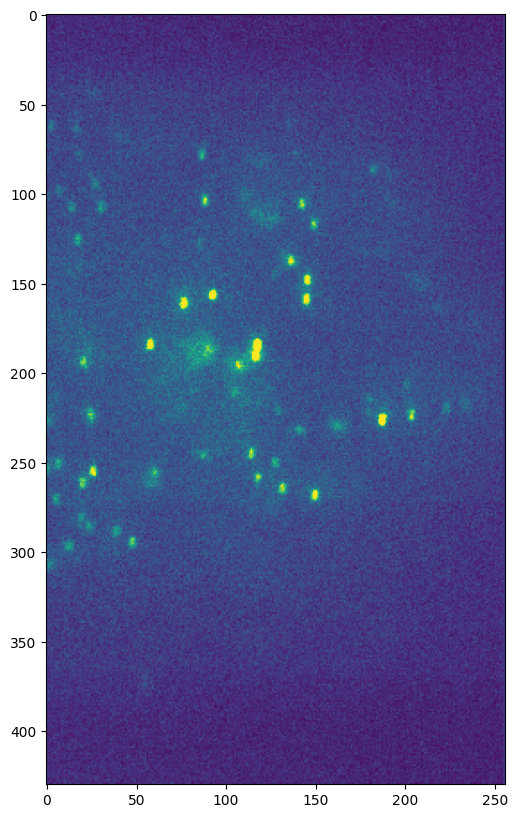

In [27]:
plt.figure(figsize=(10, 10))
plt.imshow(images[1][0],clim=(0, np.quantile(images,0.999)))

Image size: (256, 256)


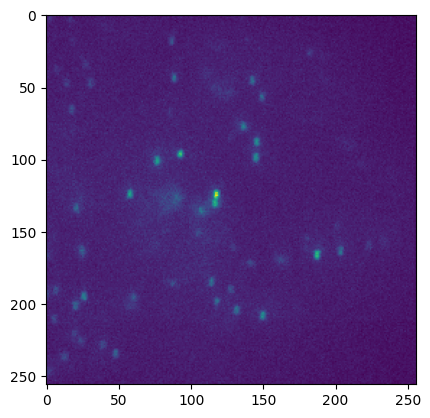

In [29]:
imsz = 256
startx = 0
starty = 60
plt.imshow(images[1][0][starty:starty+imsz,startx:startx+imsz])
print('Image size:', images[0][0][starty:starty+imsz,startx:startx+imsz].shape)

In [30]:
L.param.FOV.startx = startx
L.param.FOV.starty = starty
L.param.FOV.imsz = imsz
images = images[:,:,starty:starty+imsz,startx:startx+imsz]

rois shape channel 0: (3745, 15, 15)
rois shape channel 1: (3799, 15, 15)


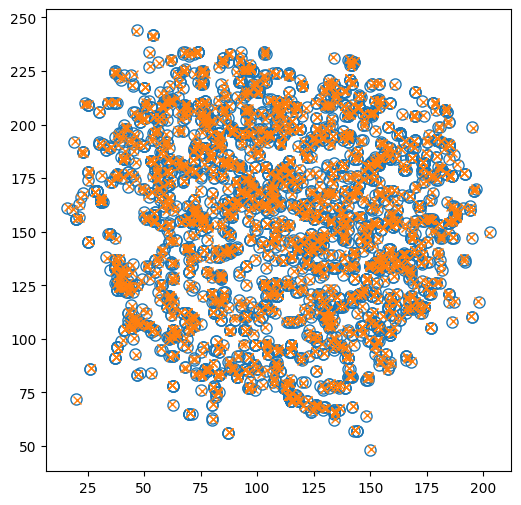

rois shape channel 0: (3327, 15, 15)
rois shape channel 1: (3327, 15, 15)


In [31]:
L.getpsfclass()
L.param.roi.roi_size = [15,15]
L.param.roi.peak_height = 0.5
dataobj = L.prep_data(images)

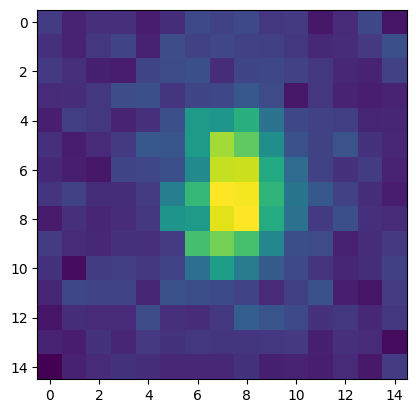

In [32]:
plt.imshow(dataobj.channels[1].rois[0])

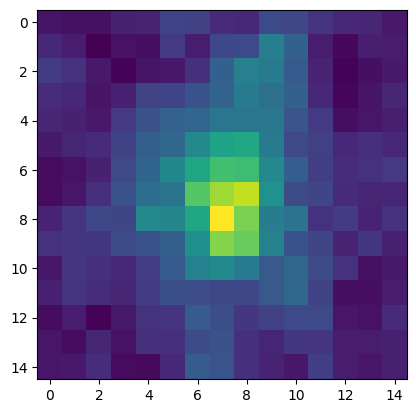

In [33]:
plt.imshow(np.max(dataobj.channels[1].rois, axis=0))

4/6: calculating spline coefficients: 1/1 [00:00s]  4.66it/s total time: 0.21s
5/6: localization: 2/2 [00:00s] 35.50it/s total time: 0.27s
4/6: calculating spline coefficients: 1/1 [00:00s]  4.65it/s total time: 0.48s
5/6: localization: 2/2 [00:00s] 35.83it/s total time: 0.54s
4/6: calculating spline coefficients: 1/1 [00:00s]  4.65it/s total time: 0.75s
5/6: localization: 2/2 [00:00s] 34.88it/s total time: 0.81s
4/6: calculating spline coefficients: 1/1 [00:00s]  4.65it/s total time: 1.02s
5/6: localization: 2/2 [00:00s] 35.65it/s total time: 1.08s
4/6: calculating spline coefficients: 1/1 [00:00s]  4.64it/s total time: 1.29s
5/6: localization: 2/2 [00:00s] 35.80it/s total time: 1.35s
4/6: calculating spline coefficients: 1/1 [00:00s]  4.66it/s total time: 1.56s
5/6: localization: 2/2 [00:00s] 34.78it/s total time: 1.62s
4/6: calculating spline coefficients: 1/1 [00:00s]  4.64it/s total time: 1.83s
5/6: localization: 2/2 [00:00s] 35.54it/s total time: 1.88s
4/6: calculating spline coe

outlier percentage: 0.2404692082111437
rois shape channel 0: (518, 15, 15)
rois shape channel 1: (518, 15, 15)


3/6: learning: 210/250 [00:31s]  6.61it/s, current loss: 1.03056, total time: 91.95s
4/6: calculating spline coefficients: 2/2 [00:00s]  4.61it/s total time: 0.43s
5/6: localization: 2/2 [00:00s]  6.11it/s total time: 0.76s
6/6: saving results: [00:00s] total time: 1.32s


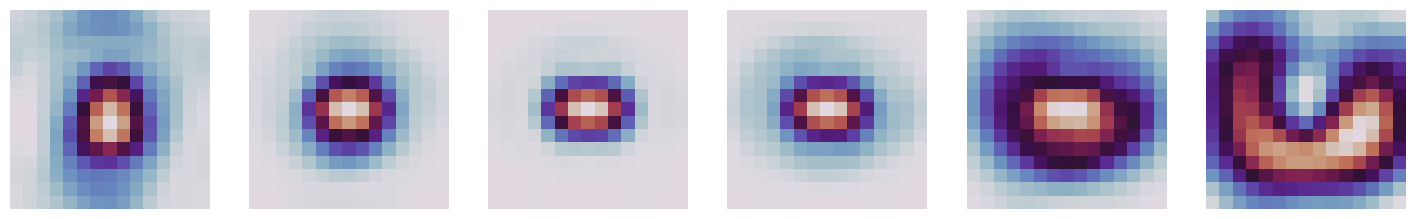

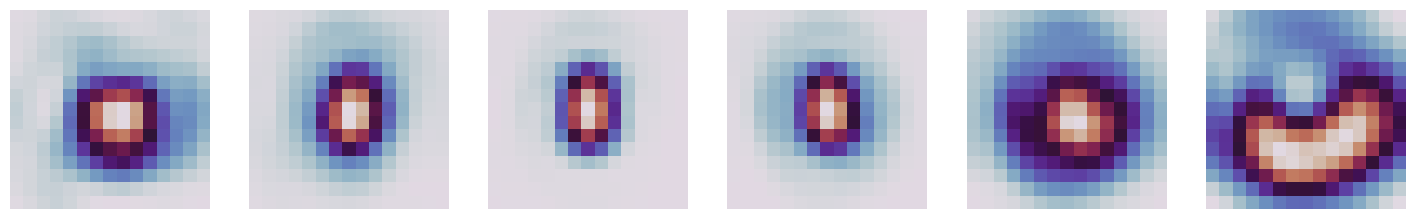

4/6: calculating spline coefficients: 1/1 [00:00s]  4.56it/s total time: 0.22s
5/6: localization: 2/2 [00:00s] 38.09it/s total time: 0.27s
3/6: learning: 53/100 [00:13s]  3.90it/s, current loss: 0.59592, total time: 13.60s
4/6: calculating spline coefficients: 1/1 [00:00s]  4.37it/s total time: 13.83s
5/6: localization: 2/2 [00:00s] 44.44it/s total time: 13.88s
3/6: learning: 52/100 [00:13s]  3.90it/s, current loss: 0.61275, total time: 26.94s
4/6: calculating spline coefficients: 2/2 [00:00s]  4.60it/s total time: 0.43s
5/6: localization: 2/2 [00:00s]  3.06it/s total time: 1.08s
3/6: learning: 209/250 [00:32s]  6.35it/s, current loss: 1.06891, total time: 59.84s


outlier percentage: 0.2520064205457464
rois shape channel 0: (466, 15, 15)
rois shape channel 1: (466, 15, 15)


3/6: learning: 206/250 [00:17s] 11.76it/s, current loss: 1.02042, total time: 77.35s
4/6: calculating spline coefficients: 2/2 [00:00s]  4.60it/s total time: 0.43s
5/6: localization: 2/2 [00:00s]  5.82it/s total time: 0.77s
6/6: saving results: [00:00s] total time: 1.33s


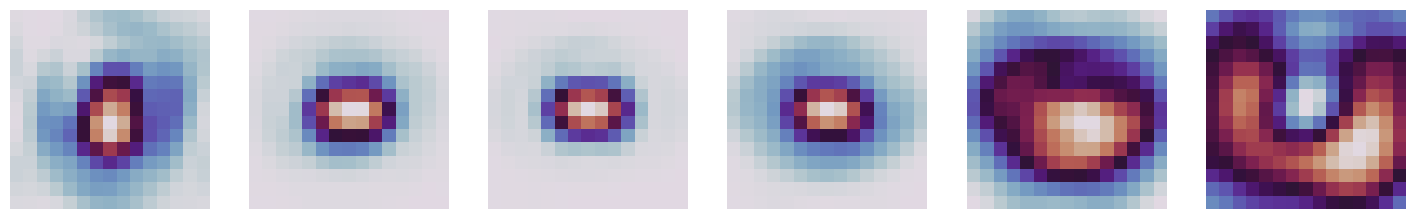

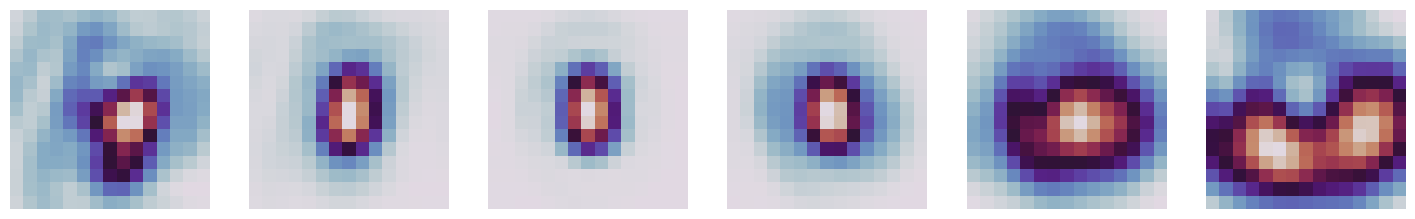

In [34]:
resfile = L.iterlearn_psf(dataobj,time=0)

#### Show results

In [35]:
f,p = io.h5.load(resfile) # load result file

channel 0


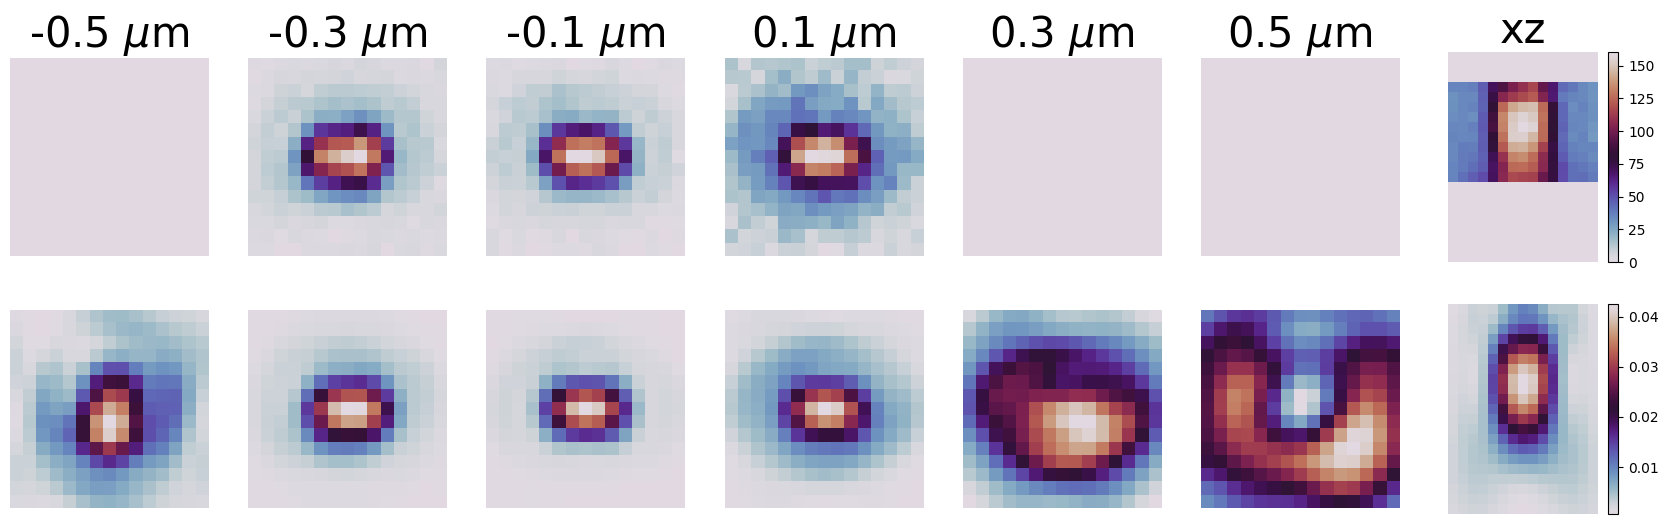

channel 1


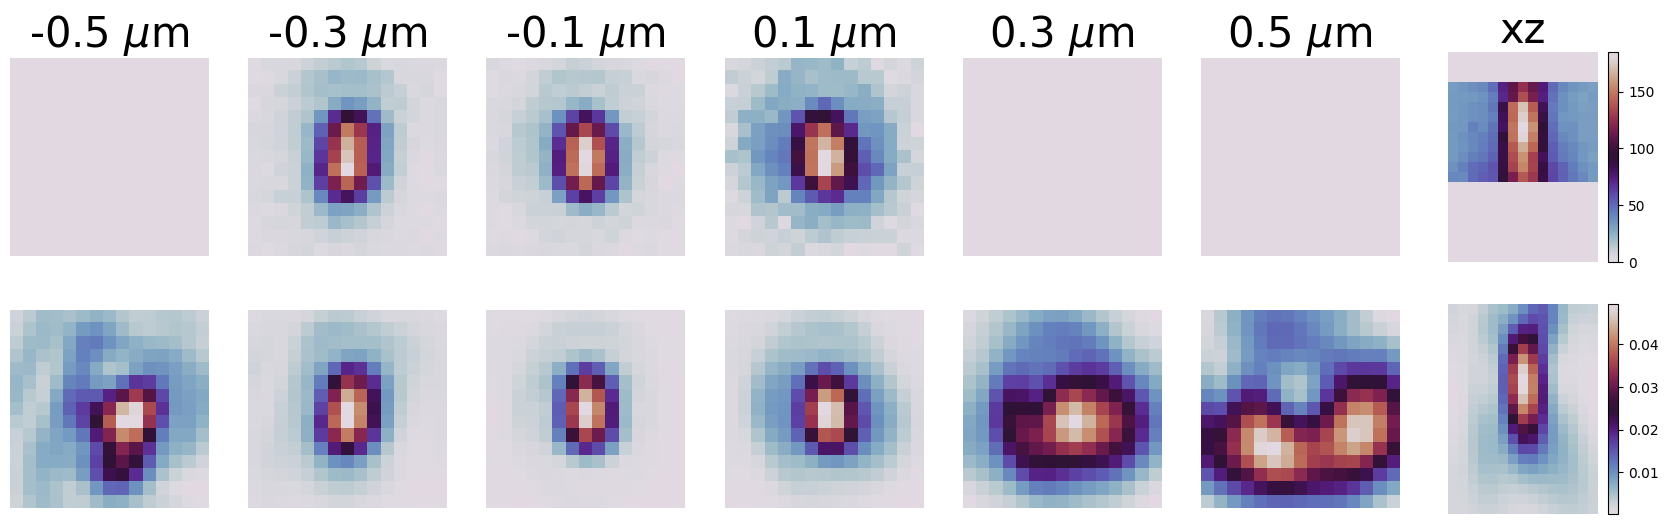

In [36]:
showpsfvsdata_insitu(f,p)

In [37]:
f.res.channel1.stagepos

array([0.8664], dtype=float32)

In [38]:
[f.res.channel0.sigma,f.res.channel1.sigma]

[array([0.6515, 0.6279], dtype=float32),
 array([0.6509, 0.6072], dtype=float32)]

#### Optional plots

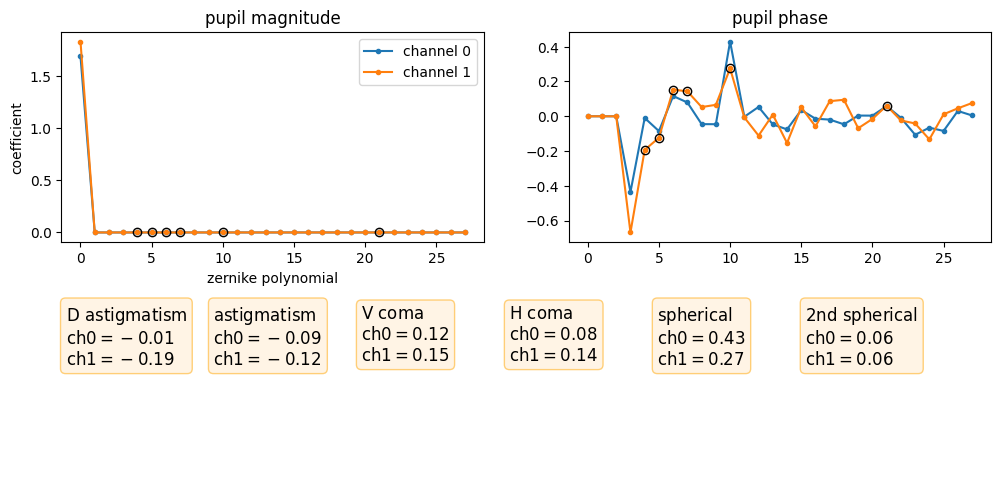

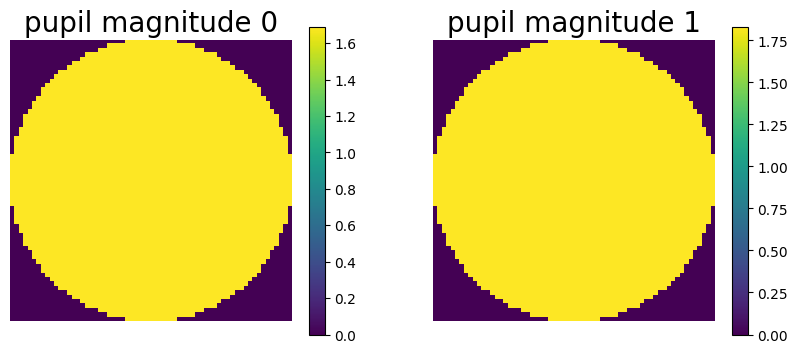

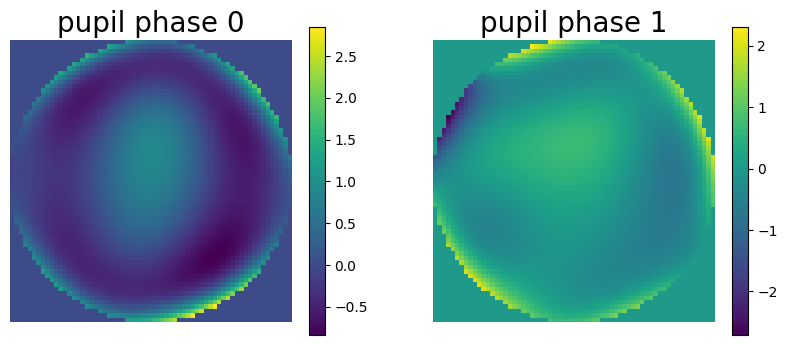

In [39]:
try:
    showzernike(f,p)
except:
    try: 
        showpupil(f,p)
    except:
        print('no pupil')

[[  0.9995  -0.0018   0.    ]
 [  0.0018   0.9984   0.    ]
 [-11.321   -4.3525   1.    ]]


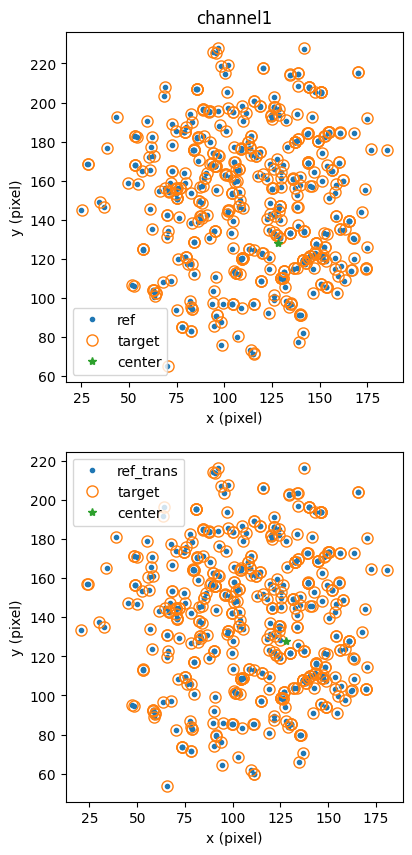

In [40]:
showtransform(f)
np.set_printoptions(precision=4,suppress=True)
print(f.res.T)

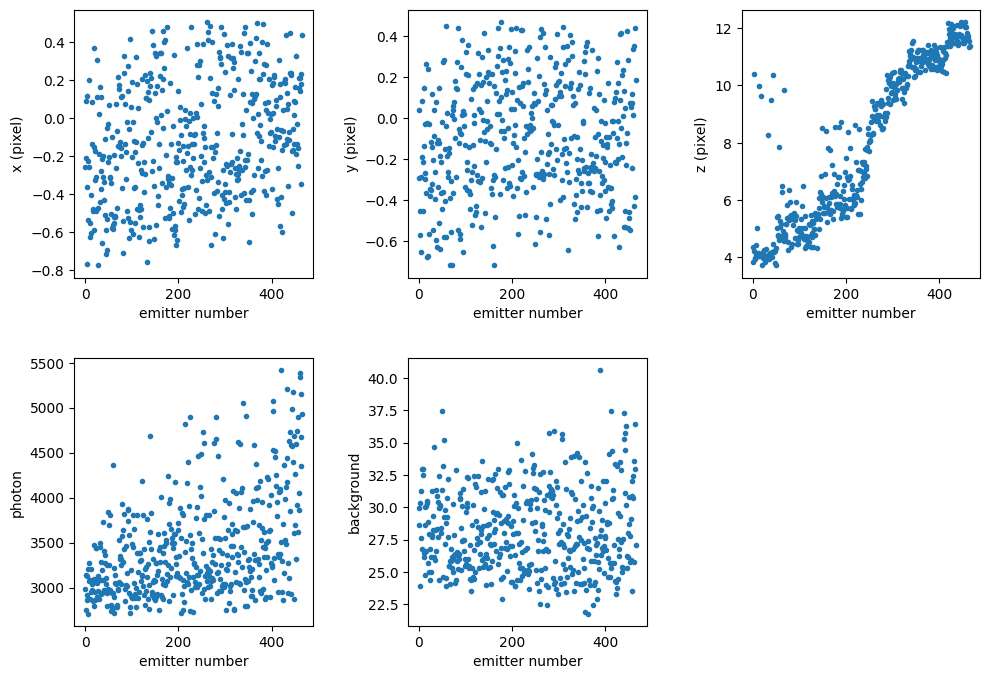

In [41]:
showlearnedparam_insitu(f,p)

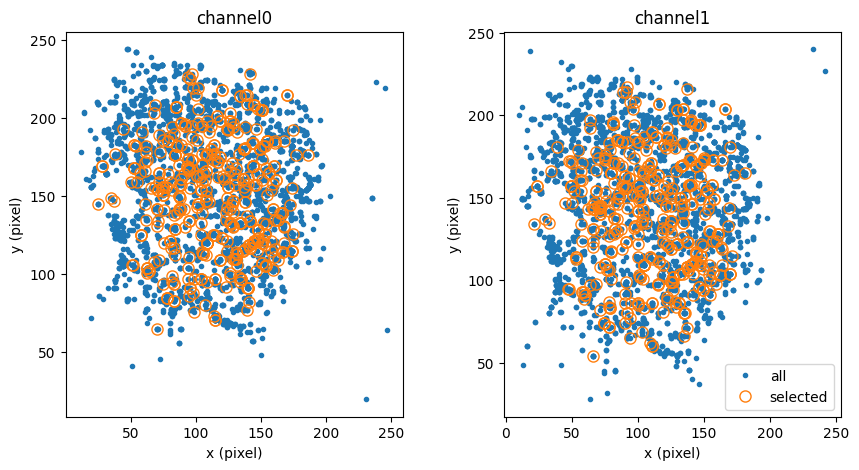

In [42]:
showcoord(f,p)

#### Ouput parameters

In [43]:
print('f:\n    ',list(f.keys()))
print(' locres:\n    ',list(f.locres.keys()))
print(' res:\n    ',list(f.res.keys()))
print(' rois:\n    ',list(f.rois.keys()))

f:
     ['locres', 'res', 'rois']
 locres:
     ['CRLB', 'LL', 'P', 'coeff', 'coeff_bead', 'coeff_reverse', 'loc']
 res:
     ['T', 'channel0', 'channel1', 'imgcenter', 'xyshift']
 rois:
     ['cor', 'fileID', 'image_size', 'psf_data', 'psf_fit']
